In [ ]:
# !unzip -q /content/dataset_clean.zip -d /content/

In [ ]:
import os

CLEAN_DIR = "/content/dataset_clean"

if not os.path.exists(CLEAN_DIR):
    print(f"KHÔNG TÌM THẤY THƯ MỤC: {CLEAN_DIR}")
    print("Các thư mục hiện có trong /content/ là:", os.listdir("/content/"))
else:
    print(f"Đã tìm thấy {CLEAN_DIR}. Đang kiểm tra bên trong...")
    classes = os.listdir(CLEAN_DIR)
    print(f"Các thư mục con (nhãn): {classes}")

    for cls in classes:
        class_path = os.path.join(CLEAN_DIR, cls)
        if os.path.isdir(class_path):
            files = os.listdir(class_path)
            print(f"  -> Nhãn '{cls}' có {len(files)} file.")

Đã tìm thấy /content/dataset_clean. Đang kiểm tra bên trong...
Các thư mục con (nhãn): ['empty', 'sleep', 'active', 'reading']
  -> Nhãn 'empty' có 487 file.
  -> Nhãn 'sleep' có 296 file.
  -> Nhãn 'active' có 694 file.
  -> Nhãn 'reading' có 549 file.


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

CLEAN_DIR = "/content/dataset_clean"
classes = ['empty', 'reading', 'sleep', 'active']

X = [] 
y = [] 

print("Đang load dữ liệu vào RAM...")
for idx, cls in enumerate(classes):
    class_dir = os.path.join(CLEAN_DIR, cls)
    for file in os.listdir(class_dir):
        if file.endswith('.pgm'):
            file_path = os.path.join(class_dir, file)

            # Đọc grayscale
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                X.append(img)
                y.append(idx)

# Chuyển thành mảng Numpy
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

# Chuẩn hóa dữ liệu ảnh từ [0-255] về [0.0 - 1.0]
X = X / 255.0

# Reshape ảnh (96, 96) -> (96, 96, 1)
X = np.expand_dims(X, axis=-1)

# Chuyển đổi nhãn sang dạng One-hot encoding
y = to_categorical(y, num_classes=len(classes))

# 80/20 train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- THÔNG SỐ DATASET SẴN SÀNG HUẤN LUYỆN ---")
print(f"Tổng số mẫu ảnh: {X.shape[0]}")
print(f"Kích thước tập Train (X_train): {X_train.shape} | Nhãn (y_train): {y_train.shape}")
print(f"Kích thước tập Test  (X_test):  {X_test.shape}  | Nhãn (y_test):  {y_test.shape}")

Đang load dữ liệu vào RAM...

--- THÔNG SỐ DATASET SẴN SÀNG HUẤN LUYỆN ---
Tổng số mẫu ảnh: 2026
Kích thước tập Train (X_train): (1620, 96, 96, 1) | Nhãn (y_train): (1620, 4)
Kích thước tập Test  (X_test):  (406, 96, 96, 1)  | Nhãn (y_test):  (406, 4)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_esp32_optimized_model(input_shape=(96, 96, 1), num_classes=4):
    model = models.Sequential(name="Shallow_CNN_ESP_DL")

  
    model.add(layers.Conv2D(16, (3, 3), strides=(2, 2), padding='same', activation='relu', input_shape=input_shape))

    
    model.add(layers.DepthwiseConv2D((3, 3), dilation_rate=(2, 2), padding='same', activation='relu'))
    model.add(layers.Conv2D(32, (1, 1), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

   
    model.add(layers.DepthwiseConv2D((3, 3), padding='same', activation='relu'))
    model.add(layers.Conv2D(64, (1, 1), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

   
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Khởi tạo mô hình
model = create_esp32_optimized_model()
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Shallow_CNN_ESP_DL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 48, 48, 16)     │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 24, 24, 32)     │           320 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

print("--- KIỂM TRA MẢNG DỮ LIỆU ---")
print(f"Giá trị pixel lớn nhất: {np.max(X_train)}")
print(f"Giá trị pixel nhỏ nhất: {np.min(X_train)}")
print(f"Kích thước X_train: {X_train.shape}")

--- KIỂM TRA MẢNG DỮ LIỆU ---
Giá trị pixel lớn nhất: 1.0
Giá trị pixel nhỏ nhất: 0.007843137718737125
Kích thước X_train: (1620, 96, 96, 1)


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,     
    width_shift_range=0.1,  
    height_shift_range=0.1, 
    zoom_range=0.1,        
    horizontal_flip=True    
)


model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# callback
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('esp32_smart_room_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# train
print("Training...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    # X_train,y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Training...
Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3414 - loss: 1.3775
Epoch 1: val_accuracy improved from None to 0.34236, saving model to esp32_smart_room_best.h5



Epoch 1: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.3420 - loss: 1.3669 - val_accuracy: 0.3424 - val_loss: 1.3430
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3990 - loss: 1.3299
Epoch 2: val_accuracy improved from 0.34236 to 0.46305, saving model to esp32_smart_room_best.h5



Epoch 2: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.4407 - loss: 1.2975 - val_accuracy: 0.4631 - val_loss: 1.2207
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4945 - loss: 1.1998
Epoch 3: val_accuracy improved from 0.46305 to 0.53941, saving model to esp32_smart_room_best.h5



Epoch 3: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.5204 - loss: 1.1516 - val_accuracy: 0.5394 - val_loss: 1.0708
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5476 - loss: 1.0856
Epoch 4: val_accuracy improved from 0.53941 to 0.61576, saving model to esp32_smart_room_best.h5



Epoch 4: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.5586 - loss: 1.0795 - val_accuracy: 0.6158 - val_loss: 1.0325
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5485 - loss: 1.0836
Epoch 5: val_accuracy improved from 0.61576 to 0.66995, saving model to esp32_smart_room_best.h5


...


Epoch 55: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 0.7605 - loss: 0.5938 - val_accuracy: 0.9187 - val_loss: 0.3837
Epoch 56/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7623 - loss: 0.5928
Epoch 56: val_accuracy did not improve from 0.91872
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.7568 - loss: 0.5993 - val_accuracy: 0.8670 - val_loss: 0.4032
Epoch 57/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7260 - loss: 0.6505
Epoch 57: val_accuracy did not improve from 0.91872
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7500 - loss: 0.6094 - val_accuracy: 0.8867 - val_loss: 0.4045
Epoch 58/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7525 - loss: 0.5938
Epoch 58: val_accuracy did not improve from 0.91872
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.7574 - loss: 0.5975 - val_accuracy: 0.9187 - val_loss: 0.3983
Epoch 59/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/st


Epoch 59: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.7741 - loss: 0.5975 - val_accuracy: 0.9335 - val_loss: 0.3799
Epoch 60/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7746 - loss: 0.5663
Epoch 60: val_accuracy did not improve from 0.93350
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.7716 - loss: 0.5708 - val_accuracy: 0.9310 - val_loss: 0.3572
Epoch 61/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7717 - loss: 0.5636
Epoch 61: val_accuracy did not improve from 0.93350
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.7741 - loss: 0.5804 - val_accuracy: 0.9015 - val_loss: 0.3722
Epoch 62/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7845 - loss: 0.5480
Epoch 62: val_accuracy did not improve from 0.93350
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.7932 - loss: 0.5483 - val_accuracy: 0.9261 - val_loss: 0.3450
Epoch 63/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/st


Epoch 68: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.7870 - loss: 0.5316 - val_accuracy: 0.9458 - val_loss: 0.3228
Epoch 69/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7994 - loss: 0.5188
Epoch 69: val_accuracy did not improve from 0.94581
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.7864 - loss: 0.5386 - val_accuracy: 0.9138 - val_loss: 0.3249
Epoch 70/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8337 - loss: 0.4759
Epoch 70: val_accuracy did not improve from 0.94581
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.8136 - loss: 0.4947 - val_accuracy: 0.9384 - val_loss: 0.3048
Epoch 71/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7924 - loss: 0.5347
Epoch 71: val_accuracy did not improve from 0.94581
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.7821 - loss: 0.5446 - val_accuracy: 0.9360 - val_loss: 0.3334
Epoch 72/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/st


Epoch 79: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.8123 - loss: 0.4885 - val_accuracy: 0.9507 - val_loss: 0.2879
Epoch 80/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8380 - loss: 0.4513
Epoch 80: val_accuracy did not improve from 0.95074
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.8160 - loss: 0.4816 - val_accuracy: 0.9236 - val_loss: 0.2998
Epoch 81/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8186 - loss: 0.4853
Epoch 81: val_accuracy did not improve from 0.95074
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.8123 - loss: 0.5003 - val_accuracy: 0.9335 - val_loss: 0.2815
Epoch 82/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8344 - loss: 0.4867
Epoch 82: val_accuracy improved from 0.95074 to 0.95320, saving model to esp32_smart_room_best.h5



Epoch 82: finished saving model to esp32_smart_room_best.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.8321 - loss: 0.4617 - val_accuracy: 0.9532 - val_loss: 0.2711
Epoch 83/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8226 - loss: 0.5310
Epoch 83: val_accuracy did not improve from 0.95320
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.8167 - loss: 0.5233 - val_accuracy: 0.9236 - val_loss: 0.2964
Epoch 84/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8365 - loss: 0.4511
Epoch 84: val_accuracy did not improve from 0.95320
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8272 - loss: 0.4725 - val_accuracy: 0.9335 - val_loss: 0.2728
Epoch 85/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8183 - loss: 0.4538
Epoch 85: val_accuracy did not improve from 0.95320
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.8278 - loss: 0.4456 - val_accuracy: 0.9261 - val_loss: 0.2699
Epoch 86/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/st

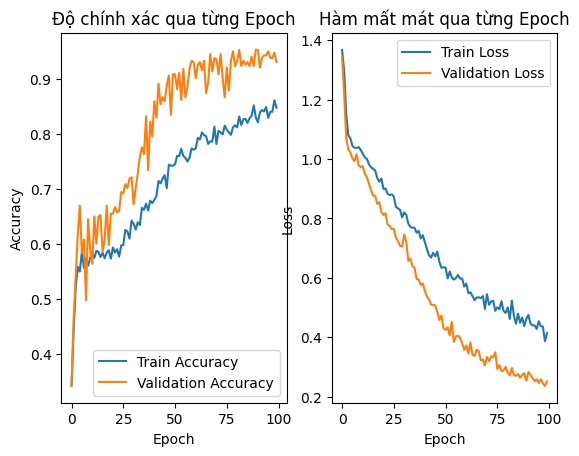


---> Độ chính xác cuối cùng trên tập Test: 94.83%


In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n---> Độ chính xác cuối cùng trên tập Test: {test_acc*100:.2f}%")

In [ ]:
import tensorflow as tf
import numpy as np
import os


MODEL_H5_PATH = 'esp32_smart_room_best.h5'
TFLITE_MODEL_PATH = 'esp32_smart_room_quantized.tflite'

print("Đang tải mô hình H5...")
model = tf.keras.models.load_model(MODEL_H5_PATH)


def representative_dataset():

    for i in range(100):
        img = X_train[i]
        img = np.expand_dims(img, axis=0) # Đưa về shape (1, 96, 96, 1)
        yield [img.astype(np.float32)]

# TFLite Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)


converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Ép thành INT8
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Ép kiểu dữ liệu Đầu vào (Input) và Đầu ra (Output) thành INT8
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# quantize
print("Đang thực hiện lượng tử hóa (có thể mất vài chục giây)...")
tflite_quant_model = converter.convert()

# save
with open(TFLITE_MODEL_PATH, 'wb') as f:
    f.write(tflite_quant_model)

# size comparison
h5_size = os.path.getsize(MODEL_H5_PATH) / 1024
tflite_size = os.path.getsize(TFLITE_MODEL_PATH) / 1024

print("\Lượng tử hóa thành công!")
print(f"Kích thước file gốc (.h5): {h5_size:.2f} KB")
print(f"Kích thước file nén (.tflite): {tflite_size:.2f} KB")
print(f"-> Mô hình đã giảm {h5_size / tflite_size:.1f} lần dung lượng")

Đang tải mô hình H5...
Đang thực hiện lượng tử hóa (có thể mất vài chục giây)...
Saved artifact at '/tmp/tmp9u3gz_5z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137978894923536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978894924880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978894925072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978391102288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978391102096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978391106320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978894919504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978894918160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978391106128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137978

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



Lượng tử hóa thành công!
Kích thước file gốc (.h5): 96.41 KB
Kích thước file nén (.tflite): 13.99 KB
-> Mô hình đã giảm 6.9 lần dung lượng!


In [ ]:
!apt-get update && apt-get install -y xxd

In [ ]:
!xxd -i esp32_smart_room_quantized.tflite > model_data.h

In [ ]:
!head -n 20 model_data.h

unsigned char esp32_smart_room_quantized_tflite[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x88, 0x00, 0x00, 0x00, 0xe0, 0x00, 0x00, 0x00, 0x08, 0x13, 0x00, 0x00,
  0x18, 0x13, 0x00, 0x00, 0xf4, 0x36, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0xba, 0xe9, 0xff, 0xff,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x94, 0xff, 0xff, 0xff, 0x1e, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
  0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0xbe, 0xec, 0xff, 0xff, 0x04, 0x